# **1. Tool Calling Agent**
Tool Calling Agent는 자신이 가진 지식만 사용하는 것이 아니라, 외부 도구(API, 데이터베이스, 코드 실행기 등)를 호출해 문제를 해결하는 에이전트입니다. 사용자의 질문을 이해한 뒤 필요한 경우 적절한 툴을 선택하고, 입력값을 구성해 호출하며, 반환된 결과를 다시 가공해 최종 답변을 만듭니다. 쉽게 말해, 단순히 대화만 하는 AI가 아니라 “필요할 때 계산기, 검색엔진, 데이터 조회 도구 같은 도구를 직접 쓸 수 있는 AI”가 Tool Calling Agent입니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FckV9NZ%2FbtsQrlsFwir%2FAAAAAAAAAAAAAAAAAAAAAAxIMYi9tK6eJ-KNQuSM2zqJOtMcskhXOI1uxBSHaUi6%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DB7thyu6eb%252FyZtWpVGP%252Bfrpl%252FvMQ%253D'>

# **2. 웹 검색을 하는 챗봇**

### 1. Tavily
- Tavily는 웹을 실시간으로 검색해 AI가 최신·정확한 정보를 답변할 수 있도록 돕는 AI용 검색·브라우징 API 플랫폼입니다.
- API 키발급(https://app.tavily.com/home)

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FY4GeO%2FbtsQsKLRhq6%2FAAAAAAAAAAAAAAAAAAAAAMizSCUaUxDXbYigO8OiZZSc9Pv7xVZ7Ob2s-5MsL35r%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DAUtENQwxfbuNl6v1qAXPbYWH2%252F8%253D'>

In [ ]:
!pip install -U tavily-python

In [13]:
import getpass
import os

In [14]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f'{var}: ')

In [15]:
_set_env("TAVILY_API_KEY")
_set_env("OPENAI_API_KEY")

TAVILY_API_KEY: ··········
OPENAI_API_KEY: ··········


In [ ]:
from tavily import TavilyClient

In [ ]:
tavily_client = TavilyClient()

In [ ]:
# max_results=3  → 검색 결과의 최대 개수를 지정합니다. 3이므로, 검색 결과를 최대 3개까지 가져옵니다.
# topic="news" → 뉴스 기사 위주로 검색
# days=10 → 최근 10일 이내의 자료만 검색
response = tavily_client.search("What is AI Agent?", max_results=3, )
response

{'query': 'What is AI Agent?',
 'response_time': 0.6,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/AI_agent',
   'title': 'AI agent - Wikipedia',
   'content': 'In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents',
   'score': 0.9293445,
   'raw_content': None},
  {'url': 'https://aws.amazon.com/what-is/ai-agents/',
   'title': 'What are AI Agents? - Artificial Intelligence - AWS',
   'content': '# What are AI Agents? * How does an AI agent work? * What are the challenges of using AI agents? ## What are AI Agents? An artificial intelligence (AI) agent is a software program that can interact with its environment, collect data, and use that data to perform self-directed tasks that meet predetermined goals. While traditional software follows hard-coded instructions, AI agents identify the next appropriate action based on

In [ ]:
response['results']

[{'url': 'https://en.wikipedia.org/wiki/AI_agent',
  'title': 'AI agent - Wikipedia',
  'content': 'In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents',
  'score': 0.9293445,
  'raw_content': None},
 {'url': 'https://aws.amazon.com/what-is/ai-agents/',
  'title': 'What are AI Agents? - Artificial Intelligence - AWS',
  'content': '# What are AI Agents? * How does an AI agent work? * What are the challenges of using AI agents? ## What are AI Agents? An artificial intelligence (AI) agent is a software program that can interact with its environment, collect data, and use that data to perform self-directed tasks that meet predetermined goals. While traditional software follows hard-coded instructions, AI agents identify the next appropriate action based on past data and execute it without continuous human oversight. AI agents interact with their environment by collecting data through sens

In [ ]:
# get_search_context: 여러 개의 검색 결과에서 중요한 내용만 추려서 한 덩어리의 텍스트로 제공
context = tavily_client.get_search_context(query='What is AI Agent?')
context

/tmp/ipykernel_328/3095692526.py:2: DeprecationWarning: get_search_context is deprecated and will be removed in future versions.
  context = tavily_client.get_search_context(query='What is AI Agent?')


'[{"url": "https://en.wikipedia.org/wiki/AI_agent", "content": "In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents"}, {"url": "https://aws.amazon.com/what-is/ai-agents/", "content": "# What are AI Agents? * How does an AI agent work? * What are the challenges of using AI agents? ## What are AI Agents? An artificial intelligence (AI) agent is a software program that can interact with its environment, collect data, and use that data to perform self-directed tasks that meet predetermined goals. While traditional software follows hard-coded instructions, AI agents identify the next appropriate action based on past data and execute it without continuous human oversight. AI agents interact with their environment by collecting data through sensors or digital inputs. The AI agent applies the data to make an informed decision. Business teams are more productive when they delegate repetitive ta

In [ ]:
# qna_search: 한 두 문장 정도로 정리된 응답을 제공
answer = tavily_client.qna_search(query='What is AI Agent?')
answer

/tmp/ipykernel_328/949786894.py:2: DeprecationWarning: qna_search is deprecated and will be removed in future versions.
  answer = tavily_client.qna_search(query='What is AI Agent?')


'An AI agent is a software program that autonomously performs tasks, learns from data, and adapts to achieve goals without human intervention. They use machine learning and natural language processing to interact with environments and complete complex workflows. AI agents can collaborate and coordinate to optimize business processes.'

### 2. TavilySearch
- [공식 문서](https://docs.langchain.com/oss/python/integrations/providers/overview)

In [ ]:
!pip install langchain_tavily

In [ ]:
from langchain_tavily import TavilySearch

In [ ]:
tool = TavilySearch(max_results=3)
tool.invoke("What's a 'node' in LangGraph?")

{'query': "What's a 'node' in LangGraph?",
 'response_time': 0.7,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://medium.com/ai-engineering-bootcamp/a-beginners-guide-to-getting-started-with-nodes-in-langgraph-cdd551e8d79c',
   'title': "A Beginner's Guide to Getting Started with Nodes in LangGraph",
   'content': '# A Beginner’s Guide to Getting Started with Nodes in LangGraph. ## What Exactly Is a Node in LangGraph? Every time your workflow enters a node, LangGraph passes in the current **state**. If you read my earlier pieces on **reducers** and **state updates**, you’ll notice that node logic often results in new data being produced, which your reducers then merge into the global state. LangGraph takes this result, merges it into the state (thanks to reducers), and carries the updated backpack forward to the next node. You now have your **first node**. LangGraph knows: “When the workflow hits `greet_node`, run the `greet` function.”. Unde

In [ ]:
# args: Tool에 전달되는 실제 입력 값
# query: 검색할 내용
# type: 호출이 tool_call 타입이라는 것을 명시
# id: tool 호출 ID
# name: 어떤 Tool을 실행할지 지

# .invoke()는 LangChain Tool 호출 형식으로 입력을 받을 수 있습니다.
# 단순 문자열을 넣는 대신, JSON(딕셔너리) 구조로 툴 호출 이벤트(tool call event)처럼 전달하는 방식입니다.

invoke_with_toolcall = tool.invoke({"args": {'query': "What's a 'node' in LangGraph?"}, "type": "tool_call", "id": "foo", "name": "tavily_search"})
invoke_with_toolcall

ToolMessage(content='{"query": "What\'s a \'node\' in LangGraph?", "response_time": 1.31, "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://medium.com/ai-engineering-bootcamp/a-beginners-guide-to-getting-started-with-nodes-in-langgraph-cdd551e8d79c", "title": "A Beginner\'s Guide to Getting Started with Nodes in LangGraph", "content": "# A Beginner’s Guide to Getting Started with Nodes in LangGraph. ## What Exactly Is a Node in LangGraph? Every time your workflow enters a node, LangGraph passes in the current **state**. If you read my earlier pieces on **reducers** and **state updates**, you’ll notice that node logic often results in new data being produced, which your reducers then merge into the global state. LangGraph takes this result, merges it into the state (thanks to reducers), and carries the updated backpack forward to the next node. You now have your **first node**. LangGraph knows: “When the workflow hits `greet_node`, run the `greet` f

In [ ]:
invoke_with_toolcall.content

'{"query": "What\'s a \'node\' in LangGraph?", "response_time": 1.31, "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://medium.com/ai-engineering-bootcamp/a-beginners-guide-to-getting-started-with-nodes-in-langgraph-cdd551e8d79c", "title": "A Beginner\'s Guide to Getting Started with Nodes in LangGraph", "content": "# A Beginner’s Guide to Getting Started with Nodes in LangGraph. ## What Exactly Is a Node in LangGraph? Every time your workflow enters a node, LangGraph passes in the current **state**. If you read my earlier pieces on **reducers** and **state updates**, you’ll notice that node logic often results in new data being produced, which your reducers then merge into the global state. LangGraph takes this result, merges it into the state (thanks to reducers), and carries the updated backpack forward to the next node. You now have your **first node**. LangGraph knows: “When the workflow hits `greet_node`, run the `greet` function.”. Under the

In [90]:
!pip install langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [ ]:
tool = TavilySearchResults(max_results=2)
tool.invoke("What's a 'node' in LangGraph?")

/tmp/ipykernel_328/1662911626.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


[{'title': 'Understanding Core Concepts of LangGraph (Deep Dive)',
  'url': 'https://dev.to/raunaklallala/understanding-core-concepts-of-langgraph-deep-dive-1d7h',
  'content': '### 1. Nodes: The Execution Units\n\nA Node is basically “a single action.” Imagine breaking your workday into steps: checking email, making coffee, writing code, or scheduling a meeting. Each of those is a Node.\n\nIn LangGraph, a Node can be many things:\n\n A large language model call (like GPT, Gemini, or LLaMA).\n A tool (search engine lookup, calculator, weather API, database query).\n A custom function (Python function, regex cleaner, summarizer).\n\nEach Node is like a worker with a simple contract: it takes an input, does its piece of the job, and pushes out an output.\n\nEveryday example:  \n  \n Think about ordering food on a delivery app. [...] One Node takes your food order.\n Another Node calls the restaurant’s system.\n Another Node calculates delivery time. Each does one thing, and together they

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FbZpG5O%2FbtsQrobKiTq%2FAAAAAAAAAAAAAAAAAAAAADbCFTyg9nxSg-pVkRn8HRwFMpFBMhO0Gs7XceZ5uagk%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DkWnluJWP7GYYxygfzzhWphFbXeA%253D'>

In [ ]:
invoke_with_toolcall = tool.invoke({"args": {'query': "What's a 'node' in LangGraph?"}, "type": "tool_call", "id": "foo", "name": "tavily"})
invoke_with_toolcall

ToolMessage(content='[{"title": "Understanding Core Concepts of LangGraph (Deep Dive)", "url": "https://dev.to/raunaklallala/understanding-core-concepts-of-langgraph-deep-dive-1d7h", "content": "### 1. Nodes: The Execution Units\\n\\nA Node is basically “a single action.” Imagine breaking your workday into steps: checking email, making coffee, writing code, or scheduling a meeting. Each of those is a Node.\\n\\nIn LangGraph, a Node can be many things:\\n\\n A large language model call (like GPT, Gemini, or LLaMA).\\n A tool (search engine lookup, calculator, weather API, database query).\\n A custom function (Python function, regex cleaner, summarizer).\\n\\nEach Node is like a worker with a simple contract: it takes an input, does its piece of the job, and pushes out an output.\\n\\nEveryday example:  \\n  \\n Think about ordering food on a delivery app. [...] One Node takes your food order.\\n Another Node calls the restaurant’s system.\\n Another Node calculates delivery time. Each 

In [ ]:
invoke_with_toolcall.content

'[{"title": "Understanding Core Concepts of LangGraph (Deep Dive)", "url": "https://dev.to/raunaklallala/understanding-core-concepts-of-langgraph-deep-dive-1d7h", "content": "### 1. Nodes: The Execution Units\\n\\nA Node is basically “a single action.” Imagine breaking your workday into steps: checking email, making coffee, writing code, or scheduling a meeting. Each of those is a Node.\\n\\nIn LangGraph, a Node can be many things:\\n\\n A large language model call (like GPT, Gemini, or LLaMA).\\n A tool (search engine lookup, calculator, weather API, database query).\\n A custom function (Python function, regex cleaner, summarizer).\\n\\nEach Node is like a worker with a simple contract: it takes an input, does its piece of the job, and pushes out an output.\\n\\nEveryday example:  \\n  \\n Think about ordering food on a delivery app. [...] One Node takes your food order.\\n Another Node calls the restaurant’s system.\\n Another Node calculates delivery time. Each does one thing, and 

In [ ]:
invoke_with_toolcall.artifact

{'query': "What's a 'node' in LangGraph?",
 'response_time': 1.41,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://dev.to/raunaklallala/understanding-core-concepts-of-langgraph-deep-dive-1d7h',
   'title': 'Understanding Core Concepts of LangGraph (Deep Dive)',
   'content': '### 1. Nodes: The Execution Units\n\nA Node is basically “a single action.” Imagine breaking your workday into steps: checking email, making coffee, writing code, or scheduling a meeting. Each of those is a Node.\n\nIn LangGraph, a Node can be many things:\n\n A large language model call (like GPT, Gemini, or LLaMA).\n A tool (search engine lookup, calculator, weather API, database query).\n A custom function (Python function, regex cleaner, summarizer).\n\nEach Node is like a worker with a simple contract: it takes an input, does its piece of the job, and pushes out an output.\n\nEveryday example:  \n  \n Think about ordering food on a delivery app. [...] One Node takes

# **3. 토큰**
토큰은 모델이 처리하는 텍스트의 작은 단위입니다. 하나의 토큰은 단어, 부분적인 단어, 또는 심지어 공백이나 구두점일 수 있습니다. 예를 들어, "나는 학교에 간다"라는 문장은 5개의 토큰(나는, 학교, 에, 간다)으로 나눠질 수 있습니다. GPT 모델은 텍스트를 처리할 때 이 토큰들을 기반으로 학습하고, 예측을 생성합니다.

### 1. 토큰은 과금 단위로 사용
- [가격](https://openai.com/api/pricing/)
- [토큰 계산](https://platform.openai.com/tokenizer)


# **4. 도구 바인딩**

In [ ]:
from langchain_core.tools import tool

In [ ]:
'''
@tool("Search the web for information.")
def add(a: int, b: int) -> int:
    return a + b
'''

@tool
def add(a: int, b: int) -> int:
    """Add two integers and return the result."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers and return the result."""
    return a * b

tools = [add, multiply]

In [7]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 4.3 MB/s eta 0:00:00


In [8]:
from langchain_openai import ChatOpenAI

In [ ]:
llm = ChatOpenAI(model='gpt-4.1-2025-04-14')
llm_with_tools = llm.bind_tools(tools)

In [ ]:
query = "What is 3 * 12? Also, What is 11 + 49?"
llm_with_tools.invoke(query).tool_calls

[{'name': 'multiply',
  'args': {'a': 3, 'b': 12},
  'id': 'call_IstxCFPbEsgpw9xEBp6swDmI',
  'type': 'tool_call'},
 {'name': 'add',
  'args': {'a': 11, 'b': 49},
  'id': 'call_9MY7dBNGORiP0hn0OAbAwZnM',
  'type': 'tool_call'}]

In [ ]:
query = "What is 12 % 2?"
llm_with_tools.invoke(query).tool_calls

[]

In [ ]:
llm_with_tools = llm.bind_tools(tools, tool_choice={"type": "function", "function": {"name":"multiply"}})
resp = llm_with_tools.invoke("What is 3 * 12? Use tool.")
print(resp.tool_calls)

[{'name': 'multiply', 'args': {'a': 3, 'b': 12}, 'id': 'call_dioq3opVQgMxsyNy6umBtio1', 'type': 'tool_call'}]


In [9]:
from langchain_openai import ChatOpenAI

In [ ]:
tool = TavilySearch(max_results=2)
tools = [tool]

llm = ChatOpenAI(model='gpt-4.1-2025-04-14')
llm_with_tools = llm.bind_tools(tools)

In [ ]:
llm_with_tools.invoke("안녕~")

AIMessage(content='안녕하세요! 무엇을 도와드릴까요? 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1190, 'total_tokens': 1203, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_74845e84fc', 'id': 'chatcmpl-DKjHJREKGHM019pjbVt0b0u66ekc2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d00af-4c48-7f23-832a-b2ce4daed5a1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1190, 'output_tokens': 13, 'total_tokens': 1203, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
llm_with_tools.invoke("What is Langgraph?")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1192, 'total_tokens': 1212, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_975fb3ccd5', 'id': 'chatcmpl-DKjHLZeF48AxdCEG5cy29c5PHUh7z', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d00af-5173-7fa0-9090-19eeb7bc134b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'What is Langgraph?'}, 'id': 'call_qxNsRfZcMNlWE9KWKFqJkofc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1192, 'output_tokens': 20, 'total_tokens': 1212, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [ ]:
llm_with_tools.invoke("What is Langgraph?").tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'What is Langgraph?'},
  'id': 'call_FSIOjLJtP1HyPeEqCl1SFPYc',
  'type': 'tool_call'}]

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [ ]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state['messages'])]}

In [ ]:
graph_builder.add_node("chatbot", chatbot)

# **5. ToolNode**
ToolNode는 LangGraph에서 도구 호출을 실제로 실행해 주는 노드입니다. LLM이 생성한 AIMessage.tool_calls를 읽어 각 호출의 도구 이름과 인자를 매칭해 실행하고, 결과를 ToolMessage로 반환하여 그래프의 상태(대화 기록)에 추가합니다. 보통 “LLM 노드 → ToolNode → LLM 노드” 형태의 루프에서 사용되며, tools_condition 같은 조건부 엣지와 함께 붙여 LLM이 도구를 요청할 때만 ToolNode가 동작하게 합니다. 요약하면, ToolNode는 LLM의 툴 호출 계획을 실제 코드 실행으로 연결하는 브리지로, 도구 레지스트리(이름→함수/툴)만 넘겨주면 호출·에러 처리·결과 전달까지 표준화된 방식으로 처리해줍니다.

In [ ]:
import json
from langchain_core.messages import ToolMessage
from langgraph.prebuilt import ToolNode

In [ ]:
'''
AIMessage(content='', additional_kwargs={'refusal': None},
response_metadata={'token_usage': {'completion_tokens': 20,
'prompt_tokens': 1192, 'total_tokens': 1212,
'completion_tokens_details': {'accepted_prediction_tokens': 0,
'audio_tokens': 0, 'reasoning_tokens': 0,
'rejected_prediction_tokens': 0},
'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14',
'system_fingerprint': 'fp_975fb3ccd5',
'id': 'chatcmpl-DKi8D1EtUp5bJqeuzDbtPXm79vh7a',
'service_tier': 'default', 'finish_reason': 'tool_calls',
'logprobs': None}, id='lc_run--019d006c-065b-72a1-8d4c-59ce7d3cfa69-0',
tool_calls=[{'name': 'tavily_search',
'args': {'query': 'What is Langgraph?'},
'id': 'call_ATyRWaVYHmiYCjbnx1B1URww', 'type': 'tool_call'}], invalid_tool_calls=[],
usage_metadata={'input_tokens': 1192, 'output_tokens': 20, 'total_tokens': 1212,
'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
'''
# 답변 본문
# 툴 호출 정보
# 토큰 사용량
# 모델 이름
# 종료 이유
# 기타 메타데이터

# tool_calls=[]: name, args(질의), id, type
# invalid_tool_calls=[]: 모델이 툴을 호출하려다가 형식을 잘못 만든 경우 담겨지는 데이터
# token_usage: completion_tokens(입력 토큰), prompt_tokens(출력 토큰), total_tokens(합계 토큰)



"\nAIMessage(content='', additional_kwargs={'refusal': None}, \nresponse_metadata={'token_usage': {'completion_tokens': 20, \n'prompt_tokens': 1192, 'total_tokens': 1212, \n'completion_tokens_details': {'accepted_prediction_tokens': 0, \n'audio_tokens': 0, 'reasoning_tokens': 0, \n'rejected_prediction_tokens': 0}, \n'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, \n'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', \n'system_fingerprint': 'fp_975fb3ccd5', \n'id': 'chatcmpl-DKi8D1EtUp5bJqeuzDbtPXm79vh7a', \n'service_tier': 'default', 'finish_reason': 'tool_calls', \n'logprobs': None}, id='lc_run--019d006c-065b-72a1-8d4c-59ce7d3cfa69-0', \ntool_calls=[{'name': 'tavily_search', \n'args': {'query': 'What is Langgraph?'}, \n'id': 'call_ATyRWaVYHmiYCjbnx1B1URww', 'type': 'tool_call'}], invalid_tool_calls=[], \nusage_metadata={'input_tokens': 1192, 'output_tokens': 20, 'total_tokens': 1212, \n'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_d

In [ ]:
class BasicToolNode:
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")

        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call['name']].invoke(tool_call['args'])
            outputs.append(ToolMessage(content=json.dumps(tool_result),
                                       name=tool_call['name'],
                                       tool_call_id=tool_call['id']))
        return {"messages": outputs}

In [ ]:
tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node('tools', tool_node)

In [ ]:
def route_tools (state: State):
    if isinstance(state, list):
        # state = [HumanMessage(...), AIMessage(...)]
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_conditional_edges("chatbot", route_tools, {"tools": "tools", END: END})

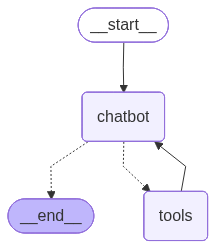

In [ ]:
graph_builder.add_edge("tools", 'chatbot')
graph_builder.add_edge(START, 'chatbot')
graph = graph_builder.compile()
graph

In [ ]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role":"user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value['messages'][-1].content)

In [ ]:
while True:
    try:
        user_input = input("User: ")
        print("User: ", user_input)
        if user_input.lower() in ['quit', 'exit', 'q']:
            print('Goodbye!')
            break
        stream_graph_updates(user_input)
    except:
        user_input = 'What do you know about LangGraph?'
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User: 안녕?
User:  안녕?
Assistant: 안녕하세요! 무엇을 도와드릴까요? 😊
User: What do you know about LangGraph?
User:  What do you know about LangGraph?
Assistant: 
Assistant: {"query": "LangGraph AI framework", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ibm.com/think/topics/langgraph", "title": "What is LangGraph? - IBM", "content": "LangGraph, created by [LangChain](https://www.ibm.com/think/topics/langchain), is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an [AI agent workflow](https://www.ibm.com/think/topics/ai-agents). The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a \u201cSuper-Map.\u201d Users can envision the [AI workflow](https://www.ibm.com/

# **6. create_react_agent**
create_react_agent는 LangChain에서 ReAct 패턴(Reason+Act)을 따르는 에이전트를 손쉽게 구성하는 팩토리로, LLM과 사용할 도구 목록, 그리고 적절한 프롬프트를 결합해 “생각→도구 호출→관찰→최종 답변”의 반복 루프를 수행하는 Agent 객체를 만들어줍니다. 이 에이전트는 질문을 해석해 필요한 도구를 선택하고 인자를 구성해 호출한 뒤, 결과를 반영해 다음 행동을 결정하며, 보통 AgentExecutor와 함께 실행하여 다단계 추론과 복수의 툴 호출을 자동으로 오케스트레이션합니다. 핵심은 프롬프트(지침), LLM, 툴 레지스트리(이름→함수/API), 출력 파서를 표준화해 붙여주는 것이며, OpenAI 스타일의 툴콜을 포함한 다양한 LLM과 호환되어 실용적인 “생각하며 도구를 쓰는” 에이전트를 빠르게 구성할 수 있게 해주는 점입니다.

In [ ]:
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI

In [ ]:
tool = TavilySearch(max_results=2)
tools = [tool]
llm = ChatOpenAI(model='gpt-5.4-2026-03-05')
agent = create_react_agent(llm, tools)

/tmp/ipykernel_328/2534176378.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools)


In [ ]:
response = agent.invoke({"messages": [{"role":"user", "content":"What is LangGraph?"}]})
response

{'messages': [HumanMessage(content='What is LangGraph?', additional_kwargs={}, response_metadata={}, id='21db922a-deee-491a-bc58-520485f4a984'),
  AIMessage(content='LangGraph is a framework for building **stateful, multi-step AI agent workflows**, especially with LLMs.\n\nIn simple terms, it lets you model an AI application as a **graph**:\n\n- **Nodes** = steps in the workflow  \n  - e.g. call an LLM, use a tool, validate output, ask for human approval\n- **Edges** = rules for what happens next  \n  - e.g. if the answer is good, finish; if not, retry or call another tool\n- **State** = shared data passed through the workflow  \n  - e.g. messages, tool results, decisions, memory\n\n### What it’s used for\nLangGraph is useful when a plain prompt or simple chain isn’t enough, such as:\n\n- AI agents that use tools\n- multi-step reasoning flows\n- workflows with loops and retries\n- human-in-the-loop systems\n- long-running tasks with persistence/checkpointing\n- multi-agent orchestratio

# **7. 원하는 형태로 출력하는 챗봇**

In [68]:
from pydantic import BaseModel, Field

In [69]:
class MovieResponse(BaseModel):
    title: str = Field(description="영화 제목")
    director: str = Field(description="감독 이름")
    genre: str = Field(description="장르")
    release_year: int = Field(description="개봉 연도")

In [70]:
model = ChatOpenAI(model='gpt-5-nano') #  gpt-5.4-2026-03-05
model_with_structured_output = model.with_structured_output(MovieResponse)
model_with_structured_output.invoke('메멘토 영화에 대해 설명해주세요')

MovieResponse(title='메멘토', director='크리스토퍼 놀런', genre='심리 스릴러 / 미스터리 / 네오누아르', release_year=2000)

In [71]:
from typing import Union

In [72]:
class MovieResponse(BaseModel):
    title: str = Field(description="영화 제목")
    director: str = Field(description="감독 이름")
    genre: str = Field(description="장르")
    release_year: int = Field(description="개봉 연도")

class ConversationalResponse(BaseModel):
    response: str = Field(description='사용자의 질문에 대해 친절하게 대화하듯 답변하는 문장')

class FinalResponse(BaseModel):
    final_output: Union[MovieResponse, ConversationalResponse]

In [73]:
structured_llm = model.with_structured_output(FinalResponse)
structured_llm.invoke('메멘토 영화에 대해 설명해주세요')

FinalResponse(final_output=ConversationalResponse(response='메멘토는 크리스토퍼 놀런이 연출하고 2000년에 개봉한 심리 스릴러 영화로, 기억과 진실의 주관성을 다룹니다. 주인공 레너드 셸비는 강한 단기 기억 상실(anterograde amnesia)을 갖고 있어 최근의 일을 오래 기억하지 못합니다. 그는 아내의 살해 사건의 복수를 꿈꾸며 단서를 남겨두기 위해 사진, 메모, 몸에 새긴 문신을 이용해 수사를 이어가는데, 이야기가 두 가지 시간 축으로 흘러가면서 관객의 신뢰를 흔듭니다.'))

In [74]:
structured_llm.invoke('메멘토 영화에 구조적으로 답해주세요')

FinalResponse(final_output=ConversationalResponse(response='메멘토의 구조는 이야기 그 자체가 주제인 영화입니다. 아래 포인트로 구조적으로 이 영화를 이해할 수 있습니다.\n\n- 이중 시점 구조\n  - 컬러 장면은 역행으로 제시되어 사건의 말미에서 시작해 점차 과거로 돌아갑니다. 매 장면은 직전 장면의 마지막으로 이어지며 시간 축이 되감깁니다.\n  - 흑백 장면은 시간의 흐름에 맞춰 순서대로 전개되어, 상대적으로 더 연속적인 맥락을 제공합니다.\n  - 두 트랙은 화면에서 교차 편집되며 하나의 전체 이야기로 합류합니다. 이로써 관객은 진실에 도달하기 위해 정보를 역추적해야 합니다.\n\n- 기억과 정보의 물리적 앵커\n  - 주인공 레너드가 남긴 타투와 메모(폴라로이드 사진)는 구조상 정보의 고정점이 되고, 시청자는 이 고정점을 통해 점진적으로 사건의 흐름을 재구성합니다.\n  - 이 기억 보조 도구는 주인공의 기억 장애를 드러내는 동시에 관객이 정보를 해석하는 방식도 결정합니다.\n\n- 주제적 구조와 서사의 신뢰성\n  - 기억의 주관성과 진실의 상대성이라는 주제가, 비선형적 구조를 통해 강화됩니다. 독자는 레너드의 서사에 의문을 품게 되고, 무엇이 ‘사실’이고 무엇이 ‘기억의 재구성’인지를 끝까지 추적하게 됩니다.\n  - 기억의 왜곡과 자기합리화의 가능성이 구조적으로 내부화되어, 보복의 강박과 그 합리화가 서사적 엔진이 됩니다.\n\n- 서사적 설계의 작동 방식\n  - 비선형 편집과 상반되는 두 시간대의 조합이 긴장감을 만들어내고, 각 트랙의 정보가 다른 시각에서 의미를 재해석하도록 만듭니다.\n  - 중심 지점에서 두 트랙이 만나며, 이야기의 결정적 해석이나 반전이 구조적으로 성립합니다. 이로써 이야기는 하나의 고정된 결말이 아니라 해석의 여지를 남깁니다.\n\n- 결과적으로 얻는 효과\n  - 관객은 주인공의 시점에 가까워지며, 기억이 어떻게 행위를 정당화하고 왜곡하는지 체험합니다.\n  - 구조

In [75]:
structured_llm.invoke('오늘 야식은 뭐 먹지?')

FinalResponse(final_output=ConversationalResponse(response='오늘 야식으로 가볍게 먹고 싶다면 아래 다섯 가지 중에서 골라봐. 모두 15분 이내로 만들 수 있어.\n- 달걀 토스트: 식빵 한 조각에 버터를 약간 바르고 계란 한 개를 올려 프라이하거나 스크램블로 만들기. 약 5분.\n- 요거트 파르페: 그릭 요거트 한 컵에 꿀 조금, 견과류 한 줌, 좋아하는 과일 조금 올리면 끝. 3–5분.\n- 바나나 + 땅콩버터 토스트: 통밀 토스트 위에 바나나 슬라이스와 땅콩버터를 얹기. 5분 이내.\n- 간단 라면 업그레이드: 라면 끓이는 동안 계란 1개를 풀어넣고, 김치 조금을 넣으면 더 든든. 5–7분.\n- 핫 오트밀 한 그릇: 오트 1/2컵을 물이나 우유에 2–3분간 끓여 취향대로 꿀/과일/견과류 추가. 5분 내외.\n\n원하는 분위기나 재료가 있으면 말해줘. 더 맞춤형으로 추천해줄게.'))

In [76]:
from langgraph.graph import MessagesState
from typing import Literal
from langchain_core.tools import tool

In [77]:
# HumanMessage(..), AIMessage(..), ToolMessage(..)
class State(MessagesState):
    final_response: MovieResponse

In [78]:
@tool
def get_movieinfo(movie: Literal['메멘토', '인터스텔라']):
    '''아래 설명은 영화에 대한 내용이야. 참고해줘'''
    if movie == '메멘토':
        return "메멘토는 단기 기억 상실증을 가진 주인공이 아내 살해 사건의 진실을 찾기 위해 메모와 문신에 의존해 사건을 추적하는 독특한 구조의 스릴러 영화입니다."
    elif movie == '인터스텔라':
        return "인터스텔라는 인류의 미래를 구하기 위해 우주로 떠난 탐사대가 사랑과 시간, 과학의 한계를 넘어서며 펼치는 감동적인 SF 영화입니다."
    else:
        raise AssertionError("알수없는 영화")

In [79]:
tools = [get_movieinfo]
model_with_tool = model.bind_tools(tools)

In [80]:
def call_model(state: State):
    response = model_with_tool.invoke(state['messages'])
    return {'messages': [response]}

In [81]:
from langchain_core.messages import HumanMessage

In [82]:
model = ChatOpenAI(model='gpt-5-nano') # gpt-5.4-2026-03-05
model_with_structured_output = model.with_structured_output(MovieResponse)

In [83]:
def respond(state: State):
    # -1: 마지막 AIMessage, -2: ToolMessage(툴 결과)
    response = model_with_structured_output.invoke(
        [HumanMessage(content=state['messages'][-2].content)]
    )
    return {'final_response': response}

In [84]:
def should_continue(state: State):
    messages = state['messages']
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "respond"
    else:
        return "continue"

In [85]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

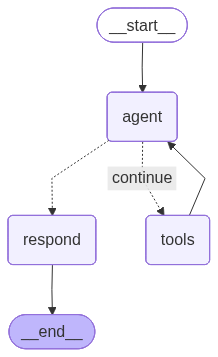

In [86]:
graph_builder = StateGraph(State)
graph_builder.add_node('agent', call_model)
graph_builder.add_node('respond', respond)
graph_builder.add_node('tools', ToolNode(tools))

graph_builder.set_entry_point('agent')
graph_builder.add_conditional_edges("agent", should_continue, {"continue": "tools", "respond": "respond"})
graph_builder.add_edge("tools", "agent")
graph_builder.add_edge("respond", END)
graph = graph_builder.compile()
graph

In [87]:
answer = graph.invoke(input={"messages": [("human", "메멘토 영화에 대해 알려주세요.")]})['final_response']
answer

MovieResponse(title='메멘토', director='크리스토퍼 놀런', genre='심리 스릴러, 미스터리', release_year=2000)

In [88]:
answer = graph.invoke(input={"messages": [("human", "메멘토 영화에 대해 알려주세요.")]})
answer

{'messages': [HumanMessage(content='메멘토 영화에 대해 알려주세요.', additional_kwargs={}, response_metadata={}, id='96e61ee9-d630-492e-997c-727b6bf31472'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 602, 'prompt_tokens': 153, 'total_tokens': 755, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 576, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DLRS2A847jNOUW9QmQzFJU1lR6stp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d0ace-3e0b-7662-8826-f20bed5b4b7b-0', tool_calls=[{'name': 'get_movieinfo', 'args': {'movie': '메멘토'}, 'id': 'call_lr29tXDhWKGn14Y2sHSPQ7dK', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 153, 'output_tokens': 602, 't

# **8. arxiv**
논문을 "출판 전에 미리 공개"하는 오픈 플랫폼입니다.
- 프리프린트
    - 정식/학회/저널에 제출되기 전 논문
    - 아직 peer review를 거치지 않았을 수 있음
    - 빠르게 공유 가능
- 무료 공개
    - 누구나 회원가입 없이 논문 열람 가능
    - PDF 다운로드 가능
    - 연구자, 학생 모두 활용 가능
- 주요 분야
    - 머신러닝/딥러닝
    - 컴퓨터 비전
    - 자연어 처리
    - 물리학, 수학, 통

In [89]:
!pip install arxiv

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.1 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=7b3be932b2a3e37192dc2fbcf7d61f03cb3241a0df0390f3c40fb95ef28ee49e
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


In [92]:
from langchain_community.utilities import ArxivAPIWrapper

In [93]:
arxiv = ArxivAPIWrapper()
docs = arxiv.run('1706.03762')
docs

'Published: 2023-08-02\nTitle: Attention Is All You Need\nAuthors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin\nSummary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 English-to-German translation task, improving over the existing best results, including ensembles by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new 

In [95]:
docs = arxiv.run('2201.12086')
docs

'Published: 2022-02-15\nTitle: BLIP: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation\nAuthors: Junnan Li, Dongxu Li, Caiming Xiong, Steven Hoi\nSummary: Vision-Language Pre-training (VLP) has advanced the performance for many vision-language tasks. However, most existing pre-trained models only excel in either understanding-based tasks or generation-based tasks. Furthermore, performance improvement has been largely achieved by scaling up the dataset with noisy image-text pairs collected from the web, which is a suboptimal source of supervision. In this paper, we propose BLIP, a new VLP framework which transfers flexibly to both vision-language understanding and generation tasks. BLIP effectively utilizes the noisy web data by bootstrapping the captions, where a captioner generates synthetic captions and a filter removes the noisy ones. We achieve state-of-the-art results on a wide range of vision-language tasks, such as image-text retr

In [97]:
docs = arxiv.run('transformer attention')
print(docs)

Published: 2023-01-16
Title: Dilated Neighborhood Attention Transformer
Authors: Ali Hassani, Humphrey Shi
Summary: Transformers are quickly becoming one of the most heavily applied deep learning architectures across modalities, domains, and tasks. In vision, on top of ongoing efforts into plain transformers, hierarchical transformers have also gained significant attention, thanks to their performance and easy integration into existing frameworks. These models typically employ localized attention mechanisms, such as the sliding-window Neighborhood Attention (NA) or Swin Transformer's Shifted Window Self Attention. While effective at reducing self attention's quadratic complexity, local attention weakens two of the most desirable properties of self attention: long range inter-dependency modeling, and global receptive field. In this paper, we introduce Dilated Neighborhood Attention (DiNA), a natural, flexible and efficient extension to NA that can capture more global context and expand 